In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import ast
from sklearn.metrics import accuracy_score
import copy
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score,average_precision_score)
from sklearn.neural_network import MLPRegressor

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
from scipy.stats import spearmanr
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance

# Load

In [4]:
path = "D:\\MissTiny\\GitHub"

In [5]:
newness = np.load(f"{path}\\Creativity_Artnet\\Datasets\\ViT_newness_2024.npy",allow_pickle=True)
surprise = np.load(f"{path}\\Creativity_Artnet\\Datasets\\ViT_surprise_2024.npy",allow_pickle=True)
value = np.load(f"{path}\\Creativity_Artnet\\Datasets\\value_2024.npy",allow_pickle=True)

In [6]:
newness = newness.squeeze()

In [7]:
surprise = surprise.squeeze()

In [8]:
BASELINE_YEAR=1600

In [9]:
gold_set_70 = pd.read_excel(f"{path}\\Creativity_Artnet\\Codes\\Evaluation\\golden_set_move_creative_70.xlsx")
creative_70 = np.load(f"{path}\\Creativity_Artnet\\Datasets\\creativity_70_full_prob.npy",allow_pickle=True)
artnet_2024 = pd.read_excel(f"{path}\\Creativity_Artnet\\Datasets\\ArtNet\\Artnet_Europe_2024_merged.xlsx")
merged_df = pd.merge(gold_set_70, artnet_2024[["artwork id","artist id","year born","workyear modifier","price","artist",'est lo usd','est hi usd', 'sale price usd']], on='artwork id', how='left')

In [10]:
gold_set_70.shape

(1874, 25)

In [11]:
artist_list = ["Pablo Picasso","Pierre-Auguste Renoir","Käthe Kollwitz"]
keep_list = merged_df["artist"].isin(artist_list)
merged_df = merged_df[keep_list]
creative_70 = creative_70[keep_list]

In [12]:
newness_df = np.zeros(merged_df.shape[0], dtype=object)
surprise_df = np.zeros(merged_df.shape[0], dtype=object)
value_df = np.zeros(merged_df.shape[0], dtype=object)
for i in range(merged_df.shape[0]):
    row_index = merged_df.index[i]
    newness_df[i] =newness[row_index]
    surprise_df[i] =surprise[row_index]
    value_df[i] = value[row_index]

The inverse of Sigmoid is Logit.

In [13]:
def logit(p, epsilon=1e-10):
    # Clip p to avoid log(0) or log(1/0)
    p = np.clip(p, epsilon, 1 - epsilon)
    return np.log(p / (1 - p))

In [14]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [15]:
def topk_hit_rate_curve(y_true, y_pred, rates):
    hit_rates = []
    n = len(y_true)

    for rate in rates:
        k = int(n * rate)
        if k == 0:
            hit_rates.append(np.nan)
            continue

        true_top_idx = np.argsort(y_true)[-k:]
        pred_top_idx = np.argsort(y_pred)[-k:]

        hit_rate = len(set(true_top_idx) & set(pred_top_idx)) / k
        hit_rates.append(hit_rate)

    return hit_rates

In [16]:
def kl_divergence(p, q, eps=1e-12):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    # Normalize (important if they are not exact probabilities)
    p = p / p.sum()
    q = q / q.sum()

    # Avoid log(0)
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)

    return np.sum(p * np.log(p / q))

# Baseline

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error
from scipy.stats import spearmanr
from sklearn.model_selection import KFold

In [18]:
epsilon=1e-6
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [19]:
y = np.log((creativity_normalized+epsilon).astype(float))
X = np.column_stack([
    np.log((newness_normalized+epsilon).astype(float)),
    np.log((surprise_normalized+epsilon).astype(float)),
    np.log((value_normalized+epsilon).astype(float))
])

y = logit(creativity_normalized,epsilon)
X = np.column_stack([
    np.log((newness_normalized+epsilon).astype(float)),
    np.log((surprise_normalized+epsilon).astype(float)),
    np.log((value_normalized+epsilon).astype(float))
])

In [20]:
kf = KFold(n_splits=5,shuffle=True,random_state=24)
kf.get_n_splits()
mses=[]
maes=[]
rmses=[]
mapes=[]

kls=[]
jss=[]
wds=[]
for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train = X[train_index]
    X_test = X[test_index]
    y_train = y[train_index]
    y_test = y[test_index]

    true_label = sigmoid(y_test)
    pred_y = sigmoid(np.repeat(np.mean(y_train), len(y_test)))

    mse = mean_squared_error(true_label, np.array(pred_y))
    # print(f"Test Linear Regression model mse: {mse:.4f}")
    mae = mean_absolute_error(true_label, pred_y)
    # print("Test mae:", mae)
    rmse = root_mean_squared_error(true_label, pred_y)
    # print("Test RMSE:", RMSE)
    mape = mean_absolute_percentage_error(true_label, pred_y)

    kl = kl_divergence(true_label, pred_y)
    # print("Test KL:", kl )
    js = jensenshannon(true_label, pred_y)**2
    # print("Test JS:", js )
    wd = wasserstein_distance(true_label, pred_y)
    # print("Test Wasserstein Distance :", wd )

    mses.append(mse)
    maes.append(mae)
    rmses.append(rmse)
    mapes.append(mape)
    
    kls.append(kl)
    jss.append(js)
    wds.append(wd)

print(f"Average mse is {np.mean(mses)}, std is {np.std(mses)}")
print(f"Average mae is {np.mean(maes)}, std is {np.std(maes)}")
print(f"Average rmse is {np.mean(rmses)}, std is {np.std(rmses)}")
print(f"Average mape is {np.mean(mapes)}, std is {np.std(mapes)}")
print("-------------------------------------------------------")
print(f"Average KL is {np.mean(kls)}, std is {np.std(kls)}")
print(f"Average JS is {np.mean(jss)}, std is {np.std(jss)}")
print(f"Average WD is {np.mean(wds)}, std is {np.std(wds)}")

Average mse is 0.0019437231089809617, std is 0.00037567028493429663
Average mae is 0.02857613823956978, std is 0.0016836443708166278
Average rmse is 0.04386495893089622, std is 0.004425888269234689
Average mape is 245.61213564085043, std is 491.01983845541855
-------------------------------------------------------
Average KL is 0.005660622667435958, std is 0.0013585385322979968
Average JS is 0.0015995368070625463, std is 0.00043450910707762137
Average WD is 0.02857613823956978, std is 0.0016836443708166285


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23)
true_label = sigmoid(y_test)
pred_y = sigmoid(np.repeat(np.mean(y_train), len(y_test)))

In [22]:
mse = mean_squared_error(true_label, np.array(pred_y))
print(f"Test Linear Regression model mse: {mse:.4f}")
mae = mean_absolute_error(true_label, pred_y)
print("Test mae:", mae)
RMSE = root_mean_squared_error(true_label, pred_y)
print("Test RMSE:", RMSE)
kl = kl_divergence(true_label, pred_y)
print("Test KL:", kl )
js = jensenshannon(true_label, pred_y)**2
print("Test JS:", js )
wd = wasserstein_distance(true_label, pred_y)
print("Test Wasserstein Distance :", wd )

Test Linear Regression model mse: 0.0028
Test mae: 0.030580785532973893
Test RMSE: 0.05326775611344636
Test KL: 0.009322230234256892
Test JS: 0.0027849167912896073
Test Wasserstein Distance : 0.030580785532973893


# Basic

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
from scipy.stats import spearmanr

In [24]:
epsilon=1e-6

In [25]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [26]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [27]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [28]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [29]:
y = np.log((creativity_normalized+epsilon).astype(float))
X = np.column_stack([
    np.log((newness_normalized+epsilon).astype(float)),
    np.log((surprise_normalized+epsilon).astype(float)),
    np.log((value_normalized+epsilon).astype(float))
])

y = logit(creativity_normalized,epsilon)
X = np.column_stack([
    #np.log((newness_normalized+epsilon).astype(float)),
    np.log((surprise_normalized+epsilon).astype(float)),
    np.log((value_normalized+epsilon).astype(float))
])

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23)

In [31]:
kf = KFold(n_splits=5,shuffle=True,random_state=24)
kf.get_n_splits()
mses=[]
maes=[]
rmses=[]
mapes=[]

kls=[]
jss=[]
wds=[]
for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train = X[train_index]
    X_test = X[test_index]
    y_train = y[train_index]
    y_test = y[test_index]

    model = LinearRegression()
    model.fit(X_train, y_train)
    
    true_label = sigmoid(y_test)
    pred_y = sigmoid(model.predict(X_test))
    
    mse = mean_squared_error(true_label, np.array(pred_y))
    # print(f"Test Linear Regression model mse: {mse:.4f}")
    mae = mean_absolute_error(true_label, pred_y)
    # print("Test mae:", mae)
    rmse = root_mean_squared_error(true_label, pred_y)
    # print("Test RMSE:", RMSE)
    mape = mean_absolute_percentage_error(true_label, pred_y)

    kl = kl_divergence(true_label, pred_y)
    # print("Test KL:", kl )
    js = jensenshannon(true_label, pred_y)**2
    # print("Test JS:", js )
    wd = wasserstein_distance(true_label, pred_y)
    # print("Test Wasserstein Distance :", wd )

    mses.append(mse)
    maes.append(mae)
    rmses.append(rmse)
    mapes.append(mape)
    
    kls.append(kl)
    jss.append(js)
    wds.append(wd)

print(f"Average mse is {np.mean(mses)}, std is {np.std(mses)}")
print(f"Average mae is {np.mean(maes)}, std is {np.std(maes)}")
print(f"Average rmse is {np.mean(rmses)}, std is {np.std(rmses)}")
print(f"Average mape is {np.mean(mapes)}, std is {np.std(mapes)}")
print("-------------------------------------------------------")
print(f"Average KL is {np.mean(kls)}, std is {np.std(kls)}")
print(f"Average JS is {np.mean(jss)}, std is {np.std(jss)}")
print(f"Average WD is {np.mean(wds)}, std is {np.std(wds)}")

Average mse is 0.0019677196458827923, std is 0.00039273371978447295
Average mae is 0.028684666336204524, std is 0.001839609860306429
Average rmse is 0.044120286295561105, std is 0.004595648276414919
Average mape is 243.88424854444398, std is 487.56431106387106
-------------------------------------------------------
Average KL is 0.005720174686034454, std is 0.0013821123375823868
Average JS is 0.0016129878607927678, std is 0.0004382139032795965
Average WD is 0.024841343669406834, std is 0.002443752347758412


In [32]:
import copy
basic_mae = copy.deepcopy(maes)
basic_rmse = copy.deepcopy(rmses)
basic_js = copy.deepcopy(jss)
basic_wd = copy.deepcopy(wds)

In [30]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [91]:
true_label = sigmoid(y_test)
pred_y = sigmoid(model.predict(X_test))

In [92]:
mse = mean_squared_error(true_label, np.array(pred_y))
print(f"Test Linear Regression model mse: {mse:.4f}")
mae = mean_absolute_error(true_label, pred_y)
print("Test mae:", mae)
RMSE = root_mean_squared_error(true_label, pred_y)
print("Test RMSE:", RMSE)
rho, pval = spearmanr(true_label, pred_y)
print("Test spearman:", rho)
kl = kl_divergence(true_label, pred_y)
print("Test KL:", kl )
js = jensenshannon(true_label, pred_y)**2
print("Test JS:", js )
wd = wasserstein_distance(true_label, pred_y)
print("Test Wasserstein Distance :", wd )

Test Linear Regression model mse: 0.0205
Test mae: 0.08649380684840621
Test RMSE: 0.14314446930697777
Test spearman: -0.0011980404027043662
Test KL: 0.016581414407014265
Test JS: 0.0047798057412544925
Test Wasserstein Distance : 0.08435379160894892


In [88]:
rate = 0.1
k = int(len(y_test) * rate)
true_top_idx = np.argsort(y_test)[-k:]
pred_top_idx = np.argsort(model.predict(X_test))[-k:]
hit_rate = len(set(true_top_idx) & set(pred_top_idx)) / k
print(f"Top {rate} Hit Rate with {k} Sample", hit_rate)

Top 0.1 Hit Rate with 37 Sample 0.05405405405405406


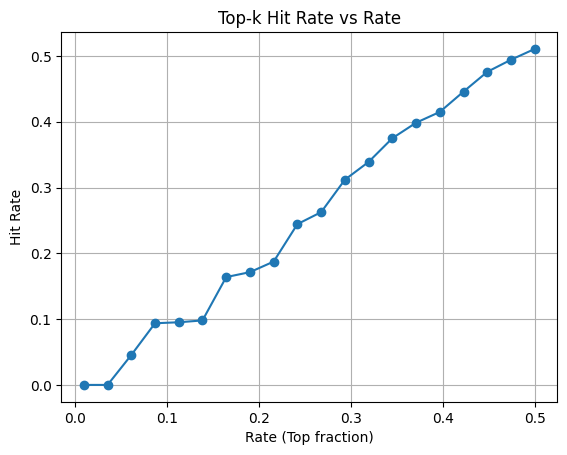

In [36]:
rates = np.linspace(0.01, 0.5, 20) 
hit_rates = topk_hit_rate_curve(y_test, pred_y, rates)
plt.figure()
plt.plot(rates, hit_rates, marker='o')
plt.xlabel("Rate (Top fraction)")
plt.ylabel("Hit Rate")
plt.title("Top-k Hit Rate vs Rate")
plt.grid(True)
plt.show()

# Splines

In [33]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [34]:
y = np.log((creativity_normalized+epsilon).astype(float))
X = np.column_stack([
    np.log((newness_normalized+epsilon).astype(float)),
    np.log((surprise_normalized+epsilon).astype(float)),
    np.log((value_normalized+epsilon).astype(float))
])

y = logit(creativity_normalized,epsilon)
X = np.column_stack([
    np.log((newness_normalized+epsilon).astype(float)),
    np.log((surprise_normalized+epsilon).astype(float)),
    np.log((value_normalized+epsilon).astype(float))
])

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23)

In [35]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=4,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [36]:
model = make_pipeline(
    preprocess,
    LinearRegression()
)

In [37]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('spline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [38]:
true_label = sigmoid(y_test)
pred_y = sigmoid(model.predict(X_test))

In [39]:
kf = KFold(n_splits=5,shuffle=True,random_state=24)
kf.get_n_splits()
mses=[]
maes=[]
rmses=[]
mapes=[]

kls=[]
jss=[]
wds=[]
for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train = X[train_index]
    X_test = X[test_index]
    y_train = y[train_index]
    y_test = y[test_index]

    model = make_pipeline(
        preprocess,
        LinearRegression()
    )
    model.fit(X_train, y_train)
    
    true_label = sigmoid(y_test)
    pred_y = sigmoid(model.predict(X_test))

    mse = mean_squared_error(true_label, np.array(pred_y))
    # print(f"Test Linear Regression model mse: {mse:.4f}")
    mae = mean_absolute_error(true_label, pred_y)
    # print("Test mae:", mae)
    rmse = root_mean_squared_error(true_label, pred_y)
    # print("Test RMSE:", RMSE)
    mape = mean_absolute_percentage_error(true_label, pred_y)

    kl = kl_divergence(true_label, pred_y)
    # print("Test KL:", kl )
    js = jensenshannon(true_label, pred_y)**2
    # print("Test JS:", js )
    wd = wasserstein_distance(true_label, pred_y)
    # print("Test Wasserstein Distance :", wd )

    mses.append(mse)
    maes.append(mae)
    rmses.append(rmse)
    mapes.append(mape)

    kls.append(kl)
    jss.append(js)
    wds.append(wd)
print(f"Average mse is {np.mean(mses)}, std is {np.std(mses)}")
print(f"Average mae is {np.mean(maes)}, std is {np.std(maes)}")
print(f"Average rmse is {np.mean(rmses)}, std is {np.std(rmses)}")
print(f"Average mape is {np.mean(mapes)}, std is {np.std(mapes)}")
print("-------------------------------------------------------")
print(f"Average KL is {np.mean(kls)}, std is {np.std(kls)}")
print(f"Average JS is {np.mean(jss)}, std is {np.std(jss)}")
print(f"Average WD is {np.mean(wds)}, std is {np.std(wds)}")

Average mse is 0.0023986055831515655, std is 0.0003110986219833175
Average mae is 0.029980139453374126, std is 0.0014361541899424368
Average rmse is 0.048874563390102085, std is 0.0031436661047983257
Average mape is 242.07039031367998, std is 483.9302743257881
-------------------------------------------------------
Average KL is 0.007696545183838449, std is 0.0015448377868504677
Average JS is 0.0019290391767159381, std is 0.0001508760794994728
Average WD is 0.02254997724210754, std is 0.002776670464741117


In [40]:
from scipy.stats import ttest_rel, ttest_ind
print(ttest_ind(basic_mae, maes))
print(ttest_ind(basic_rmse, rmses))
print(ttest_ind(basic_js, jss))
print(ttest_ind(basic_wd, wds))
print((np.mean(basic_mae) - np.mean(maes))/np.mean(maes))
print((np.mean(basic_rmse) - np.mean(rmses))/np.mean(rmses))
print((np.mean(basic_js) - np.mean(jss))/np.mean(jss))
print((np.mean(wds)-np.mean(basic_wd))/np.mean(basic_wd))

TtestResult(statistic=np.float64(-1.1101752520266512), pvalue=np.float64(0.299175282666728), df=np.float64(8.0))
TtestResult(statistic=np.float64(-1.707714593172043), pvalue=np.float64(0.12607157164768923), df=np.float64(8.0))
TtestResult(statistic=np.float64(-1.3638779187411154), pvalue=np.float64(0.209740955415745), df=np.float64(8.0))
TtestResult(statistic=np.float64(1.2389464484561916), pvalue=np.float64(0.2504811866534973), df=np.float64(8.0))
-0.04321104373728331
-0.09727508063026095
-0.16383872330743787
-0.09224003571599097


In [86]:
mse = mean_squared_error(true_label, np.array(pred_y))
print(f"Test Linear Regression model mse: {mse:.4f}")
mae = mean_absolute_error(true_label, pred_y)
print("Test mae:", mae)
RMSE = root_mean_squared_error(true_label, pred_y)
print("Test RMSE:", RMSE)
rho, pval = spearmanr(true_label, pred_y)
print("Test spearman:", rho)
kl = kl_divergence(true_label, pred_y)
print("Test KL:", kl )
js = jensenshannon(true_label, pred_y)**2
print("Test JS:", js )
wd = wasserstein_distance(true_label, pred_y)
print("Test Wasserstein Distance :", wd )
rate = 0.1
k = int(len(y_test) * rate)
true_top_idx = np.argsort(y_test)[-k:]
pred_top_idx = np.argsort(model.predict(X_test))[-k:]
hit_rate = len(set(true_top_idx) & set(pred_top_idx)) / k
print(f"Top {rate} Hit Rate with {k} Sample:", hit_rate)

Test Linear Regression model mse: 0.0168
Test mae: 0.07878773888989679
Test RMSE: 0.12979748332317897
Test spearman: 0.10202866145454655
Test KL: 0.01368535824454014
Test JS: 0.003899715600649509
Test Wasserstein Distance : 0.07275065784349051
Top 0.1 Hit Rate with 37 Sample: 0.1891891891891892


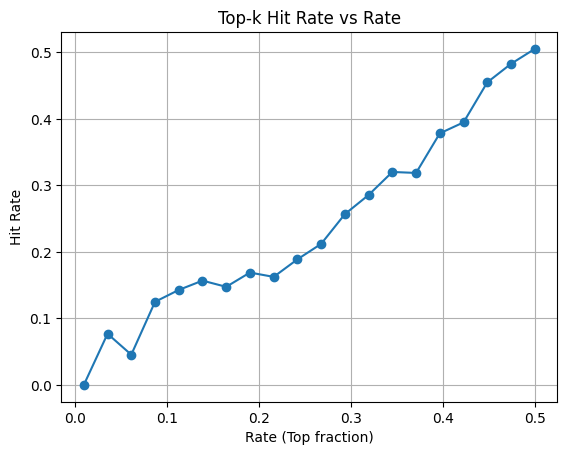

In [33]:
rates = np.linspace(0.01, 0.5, 20) 
hit_rates = topk_hit_rate_curve(y_test, pred_y, rates)
plt.figure()
plt.plot(rates, hit_rates, marker='o')
plt.xlabel("Rate (Top fraction)")
plt.ylabel("Hit Rate")
plt.title("Top-k Hit Rate vs Rate")
plt.grid(True)
plt.show()

In [34]:
hit_rates

[0.0,
 0.07692307692307693,
 0.045454545454545456,
 0.125,
 0.14285714285714285,
 0.1568627450980392,
 0.14754098360655737,
 0.16901408450704225,
 0.1625,
 0.18888888888888888,
 0.21212121212121213,
 0.25688073394495414,
 0.2857142857142857,
 0.3203125,
 0.3188405797101449,
 0.3783783783783784,
 0.39490445859872614,
 0.4550898203592814,
 0.48295454545454547,
 0.5053763440860215]

# Neural Network

In [50]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [51]:
result=[]
best_alpha=None
best_layer=None
best_score=None
for alpha in alphas:
    for layer in layers:
        model = MLPRegressor(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        X_train1, X_val, y_train1, y_val = train_test_split(X_train,y_train, test_size=0.20, random_state=23)
        model.fit(X_train1, y_train1)

        
        true_label = sigmoid(y_val)
        pred_y = sigmoid(model.predict(X_val)) 

        mse = mean_squared_error(true_label, np.array(pred_y))
        #print(f"Test Linear Regression model mse: {mse:.4f}")
        mae = mean_absolute_error(true_label, pred_y)
        #print("Test mae:", mae)
        RMSE = root_mean_squared_error(true_label, pred_y)
        #print("Test RMSE:", RMSE)
        rho, pval = spearmanr(true_label, pred_y)
        #print("Test spearman:", rho)
        if best_alpha==None:
            best_alpha = alpha
            best_layer = layer
            best_score = RMSE
        elif best_score < RMSE:
            best_alpha = alpha
            best_layer = layer
            best_score = RMSE
            
        
        result.append({'alpha':alpha,'layer':layer,'mse':mse,'mae':mae,'RMSE':RMSE,'spearman':rho})
        #print("Test F1:", f1)

In [52]:
model = MLPRegressor(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
model.fit(X_train, y_train)
true_label = sigmoid(y_test)
pred_y = sigmoid(model.predict(X_test))

In [54]:
mse = mean_squared_error(true_label, np.array(pred_y))
print(f"Test Linear Regression model mse: {mse:.4f}")
mae = mean_absolute_error(true_label, pred_y)
print("Test mae:", mae)
RMSE = root_mean_squared_error(true_label, pred_y)
print("Test RMSE:", RMSE)
rho, pval = spearmanr(true_label, pred_y)
print("Test spearman:", rho)
kl = kl_divergence(true_label, pred_y)
print("Test KL:", kl )
js = jensenshannon(true_label, pred_y)**2
print("Test JS:", js )
wd = wasserstein_distance(true_label, pred_y)
print("Test Wasserstein Distance :", wd )
rate = 0.1
k = int(len(y_test) * rate)
true_top_idx = np.argsort(y_test)[-k:]
pred_top_idx = np.argsort(model.predict(X_test))[-k:]
hit_rate = len(set(true_top_idx) & set(pred_top_idx)) / k
print(f"Top {rate} Hit Rate with {k} Sample:", hit_rate)

Test Linear Regression model mse: 0.0205
Test mae: 0.08713036210288538
Test RMSE: 0.1433441413277947
Test spearman: 0.010718079657546821
Test KL: 0.016667245878208233
Test JS: 0.004801357384871683
Test Wasserstein Distance : 0.07960630547973978
Top 0.1 Hit Rate with 37 Sample: 0.08108108108108109


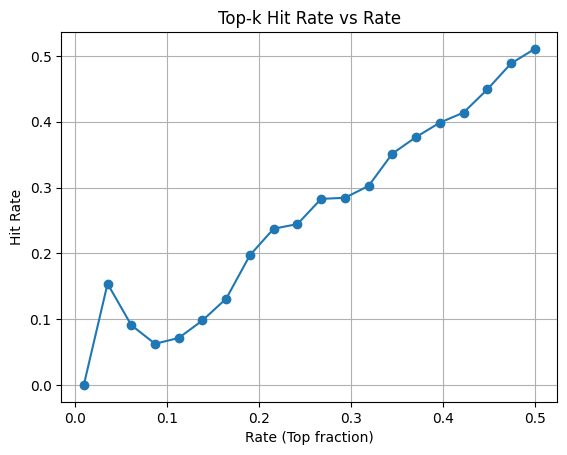

In [39]:
rates = np.linspace(0.01, 0.5, 20) 
hit_rates = topk_hit_rate_curve(true_label, pred_y, rates)
plt.figure()
plt.plot(rates, hit_rates, marker='o')
plt.xlabel("Rate (Top fraction)")
plt.ylabel("Hit Rate")
plt.title("Top-k Hit Rate vs Rate")
plt.grid(True)
plt.show()

In [40]:
hit_rates 

[0.0,
 0.15384615384615385,
 0.09090909090909091,
 0.0625,
 0.07142857142857142,
 0.09803921568627451,
 0.13114754098360656,
 0.19718309859154928,
 0.2375,
 0.24444444444444444,
 0.2828282828282828,
 0.28440366972477066,
 0.3025210084033613,
 0.3515625,
 0.37681159420289856,
 0.39864864864864863,
 0.4140127388535032,
 0.4491017964071856,
 0.48863636363636365,
 0.510752688172043]